# Sequence Classification with RNN, LSTM, and GRU

A recurrent neural network processes an input sequence one step at a time while maintaining an internal state. This makes recurrent models useful when the order of the observations matters.

In this notebook, each MNIST image is treated as a sequence of 28 rows. Each row contains 28 pixel values, so the input to the recurrent model has:

- **28 time steps**
- **28 features per time step**

The notebook develops the sequence models in the following order:

1. Simple RNN
2. LSTM
3. GRU
4. Side-by-side performance comparison


## Import Libraries


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Why Sequence Models?


Before using RNN, LSTM, and GRU, it is useful to see what makes sequential data different from ordinary fixed-feature data.

Consider these two sentences:

```text
dog bites man
man bites dog
```

They contain exactly the same words, but the order is different and the meaning is different.

A model can only learn from information that is present in its input representation. If the representation removes the order, the model cannot recover it later.


### Order-Independent Dense Representation

A common fixed-feature representation is bag-of-words. It counts how many times each word appears but does not keep the position of the words.

The following example creates bag-of-words vectors for the two sentences.


In [2]:
sentence_1 = ["dog", "bites", "man"]
sentence_2 = ["man", "bites", "dog"]

vocabulary = ["dog", "bites", "man"]

bow_1 = np.array([sentence_1.count(word) for word in vocabulary])
bow_2 = np.array([sentence_2.count(word) for word in vocabulary])

print("Sentence 1:", sentence_1)
print("Sentence 2:", sentence_2)

print("\nBag-of-words representation")
print("Sentence 1:", bow_1)
print("Sentence 2:", bow_2)

print("\nSame representation:", np.array_equal(bow_1, bow_2))


Sentence 1: ['dog', 'bites', 'man']
Sentence 2: ['man', 'bites', 'dog']

Bag-of-words representation
Sentence 1: [1 1 1]
Sentence 2: [1 1 1]

Same representation: True


Both sentences become the same vector:

```text
[1, 1, 1]
```

If a Dense network receives only these vectors, it receives exactly the same input for both sentences. Therefore, it must produce the same output for both.

This does **not** mean a Dense network can never work with sequential data. A Dense network can use a fixed-length input that preserves position. The limitation here is that an order-independent representation removes the sequential information before the model sees it.


### Dense Network on the Order-Independent Representation


In [3]:
dense_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(2, activation="softmax")
])

dense_out_1 = dense_model(np.expand_dims(bow_1, axis=0))
dense_out_2 = dense_model(np.expand_dims(bow_2, axis=0))

print("Dense output for sentence 1:", dense_out_1.numpy())
print("Dense output for sentence 2:", dense_out_2.numpy())

print(
    "Same Dense output:",
    np.allclose(dense_out_1.numpy(), dense_out_2.numpy())
)


Dense output for sentence 1: [[0.61791867 0.38208136]]
Dense output for sentence 2: [[0.61791867 0.38208136]]
Same Dense output: True


The outputs are the same because the two input vectors are the same.

Now keep the word order instead of converting the sentences to counts.


### Sequential Representation


In [4]:
word_to_index = {
    "dog": 1,
    "bites": 2,
    "man": 3
}

sequence_1 = np.array([word_to_index[word] for word in sentence_1])
sequence_2 = np.array([word_to_index[word] for word in sentence_2])

print("Sentence 1 sequence:", sequence_1)
print("Sentence 2 sequence:", sequence_2)

print(
    "Same sequential representation:",
    np.array_equal(sequence_1, sequence_2)
)


Sentence 1 sequence: [1 2 3]
Sentence 2 sequence: [3 2 1]
Same sequential representation: False


Now the order is preserved:

```text
dog → bites → man = [1, 2, 3]

man → bites → dog = [3, 2, 1]
```

A recurrent model receives one element at a time and carries a hidden state from one time step to the next.


### RNN Hidden State Changes with Sequence Order


In [5]:
sequence_1_oh = tf.one_hot(sequence_1, depth=4)
sequence_2_oh = tf.one_hot(sequence_2, depth=4)

sequence_1_oh = tf.expand_dims(sequence_1_oh, axis=0)
sequence_2_oh = tf.expand_dims(sequence_2_oh, axis=0)

rnn_demo = tf.keras.layers.SimpleRNN(
    4,
    return_sequences=True,
    return_state=True
)

output_1, state_1 = rnn_demo(sequence_1_oh)
output_2, state_2 = rnn_demo(sequence_2_oh)

print("Final hidden state for sentence 1:")
print(state_1.numpy())

print("\nFinal hidden state for sentence 2:")
print(state_2.numpy())

print(
    "\nSame final hidden state:",
    np.allclose(state_1.numpy(), state_2.numpy())
)


Final hidden state for sentence 1:
[[-0.692172   -0.8470034  -0.69283324  0.6977823 ]]

Final hidden state for sentence 2:
[[-0.5592769  -0.8846058  -0.79551667  0.70979834]]

Same final hidden state: False


The two final hidden states are different because the RNN processes the words in different orders.

The hidden state is the important feature that a normal Dense layer does not have. At time step $t$, the RNN uses both the current input and information carried from the previous time step.

```text
x1 → h1
      ↓
x2 → h2
      ↓
x3 → h3
      ↓
     output
```

The same recurrent weights are reused at every time step.


### What About CNN?

A CNN can also be used with sequential data. A 1D convolution can learn local patterns such as nearby words or short temporal patterns.

The main difference is how information is handled:

- **Dense:** no recurrent memory. It maps the input features directly to the next layer.
- **CNN:** learns local patterns inside its receptive field.
- **RNN:** carries a hidden state from one time step to the next.
- **LSTM:** adds gated memory to control what should be remembered or forgotten.
- **GRU:** uses a simpler gated memory with update and reset gates.

CNNs can capture longer relationships by using deeper layers, larger kernels, or dilation. RNN, LSTM, and GRU instead build the sequence representation by repeatedly updating a state as the sequence is processed.


### Why LSTM and GRU After RNN?

A Simple RNN has memory through its hidden state, but information from early time steps can become difficult to learn when the sequence is long. During backpropagation through many time steps, gradients can become very small or very large.

LSTM and GRU were developed to improve this behavior.

```text
Simple RNN
    ↓
hidden state carries previous information
    ↓
long sequence can be difficult to learn
    ↓
LSTM / GRU
    ↓
gates learn what information should be
remembered, updated, or forgotten
```

This progression is the reason the notebook starts with RNN and then moves to LSTM and GRU.


## Load the MNIST Dataset

The original 28 × 28 image structure is preserved. Instead of flattening each image into 784 independent features, the model receives the image row by row as a sequence.


In [6]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = np.float32(X_train) / 255.0
X_test = np.float32(X_test) / 255.0

print(f"{X_train.shape=}")
print(f"{y_train.shape=}")
print(f"{X_test.shape=}")
print(f"{y_test.shape=}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train.shape=(60000, 28, 28)
y_train.shape=(60000,)
X_test.shape=(10000, 28, 28)
y_test.shape=(10000,)


## Inspect the Sequential Representation


Image shape: (28, 28)
Number of time steps: 28
Features per time step: 28


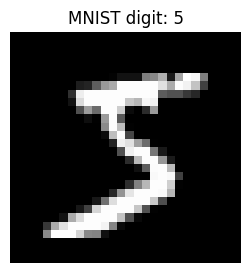

In [7]:
sample_id = 0

print("Image shape:", X_train[sample_id].shape)
print("Number of time steps:", X_train[sample_id].shape[0])
print("Features per time step:", X_train[sample_id].shape[1])

plt.figure(figsize=(3, 3))
plt.imshow(
    X_train[sample_id],
    cmap="gray",
    vmin=0,
    vmax=1,
)
plt.title(
    f"MNIST digit: {y_train[sample_id]}"
)
plt.axis("off")
plt.show()


Each row of the image is one time step:

```text
time step 1  → 28 pixel values
time step 2  → 28 pixel values
...
time step 28 → 28 pixel values
```

The recurrent layer updates its hidden state after every row and uses the accumulated information to classify the complete image.


## Training Curves


In [8]:
def plot_results(history, title):
    fig, ax = plt.subplots(
        ncols=2,
        figsize=(12, 4),
    )

    ax[0].plot(
        history.history["accuracy"],
        label="train",
    )
    ax[0].plot(
        history.history["val_accuracy"],
        label="validation",
    )
    ax[0].set_title(
        f"{title} - Accuracy"
    )
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].grid(True)
    ax[0].legend(
        loc="lower right"
    )

    ax[1].plot(
        history.history["loss"],
        label="train",
    )
    ax[1].plot(
        history.history["val_loss"],
        label="validation",
    )
    ax[1].set_title(
        f"{title} - Loss"
    )
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].grid(True)
    ax[1].legend(
        loc="upper right"
    )

    plt.show()


## Common Training Settings

The three recurrent models use the same hidden size, optimizer, batch size, validation split, and early-stopping strategy so that the comparison focuses on the recurrent layer itself.


In [9]:
hidden_units = 64
epochs = 100
batch_size = 128

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1,
)


## What Do Recurrent Sequence Models Learn?

RNN, LSTM, and GRU do not use manually specified rules for how one time step should influence another. During training, they learn the weights that determine how information from the current input and previous hidden state should be combined.

For the MNIST sequence representation used here, the model sees one image row at a time. During training it learns:

- which pixel patterns in each row are useful for recognizing a digit,
- how information from earlier rows should influence later processing,
- which sequence patterns distinguish one digit from another,
- and how the final hidden representation should be mapped to one of the 10 digit classes.

The difference among RNN, LSTM, and GRU is mainly **how they maintain and update information across the sequence**.


# 1. Simple Recurrent Neural Network

## What is an RNN?

A Recurrent Neural Network (RNN) is a neural network designed for ordered or sequential data. Instead of treating every input independently, an RNN keeps a **hidden state** that carries information from previous time steps.

At time step $t$, the network combines the current input $x_t$ with the previous hidden state $h_{t-1}$:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

The same recurrent weights are reused at every time step.

## How does it learn?

During backpropagation through time, the RNN learns:

- **input-to-hidden weights** that determine how the current input affects the hidden state,
- **hidden-to-hidden weights** that determine how previous sequence information is carried forward,
- and **output weights** that map the final learned representation to the prediction.

## What does it learn in this notebook?

For MNIST, each 28 × 28 image is treated as 28 sequential rows. The RNN learns how patterns in earlier rows combine with later rows to identify the complete digit. For example, it can learn that a curved pattern near the top followed by a particular lower-row structure is useful for distinguishing one digit from another.

A Simple RNN provides the basic recurrent mechanism, but information from early time steps can become difficult to preserve over longer sequences because of vanishing or exploding gradients.


In [10]:
rnn_model = Sequential(
    [
        Input(
            shape=(28, 28)
        ),
        SimpleRNN(
            hidden_units,
            activation="tanh",
        ),
        Dense(
            10,
            activation="softmax",
        ),
    ],
    name="simple_rnn_mnist",
)

rnn_model.summary()

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


Model: "simple_rnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,602 (25.79 KB)

 Trainable params: 6,602 (25.79 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Simple RNN


Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7723 - loss: 0.7287 - val_accuracy: 0.9062 - val_loss: 0.3278 - learning_rate: 0.0010
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9031 - loss: 0.3342 - val_accuracy: 0.9350 - val_loss: 0.2304 - learning_rate: 0.0010
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9255 - loss: 0.2583 - val_accuracy: 0.9470 - val_loss: 0.1852 - learning_rate: 0.0010
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9374 - loss: 0.2192 - val_accuracy: 0.9557 - val_loss: 0.1582 - learning_rate: 0.0010
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9462 - loss: 0.1872 - val_accuracy: 0.9583 - val_loss: 0.1490 - learning_rate: 0.0010
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9493 - loss: 0.1746 - val_accuracy: 0.9580 - val_loss: 0.1454 - learning_rate: 0.0010
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9541 - 

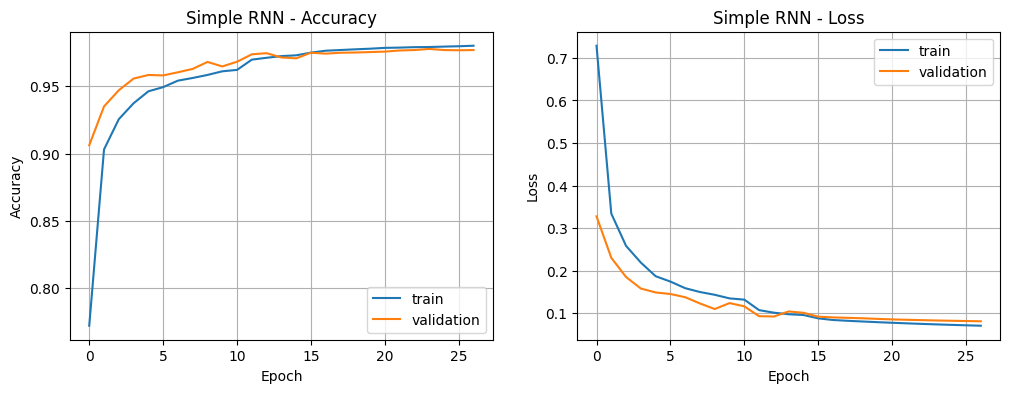

In [11]:
start_train = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[
        early_stopping,
        reduce_lr,
    ],
    verbose=1,
)

end_train = time.time()

print(
    "Training time:",
    f"{end_train - start_train:.2f} seconds",
)

plot_results(
    rnn_history,
    "Simple RNN",
)


## Evaluate the Simple RNN


In [12]:
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(
    f"Simple RNN test loss: "
    f"{rnn_test_loss:.4f}"
)
print(
    f"Simple RNN test accuracy: "
    f"{rnn_test_acc:.4f}"
)


Simple RNN test loss: 0.1224
Simple RNN test accuracy: 0.9669


# 2. Long Short-Term Memory Network

## What is an LSTM?

Long Short-Term Memory (LSTM) is a gated recurrent architecture designed to preserve useful information for longer periods than a standard RNN.

In addition to a hidden state, an LSTM maintains a **cell state** that acts as a memory path through the sequence.

The main gates are:

- **forget gate**: decides which stored information should be removed,
- **input gate**: decides which new information should be written to memory,
- **output gate**: decides which part of the memory should influence the current hidden state.

## How does it learn?

The gate values are not manually specified. Their weights are learned from the training data through backpropagation. The LSTM therefore learns when information should be remembered, updated, or forgotten.

## What does it learn in this notebook?

For the row-by-row MNIST sequence, the LSTM learns which visual information from early image rows should remain useful when later rows are processed. It can preserve important structure across the full 28-step sequence while discarding row information that is not helpful for classification.

This gated memory mechanism helps reduce the long-term dependency problem that can affect a Simple RNN.


In [13]:
lstm_model = Sequential(
    [
        Input(
            shape=(28, 28)
        ),
        LSTM(
            hidden_units
        ),
        Dense(
            10,
            activation="softmax",
        ),
    ],
    name="lstm_mnist",
)

lstm_model.summary()

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


Model: "lstm_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,458 (95.54 KB)

 Trainable params: 24,458 (95.54 KB)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM


Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.7809 - loss: 0.6946 - val_accuracy: 0.9382 - val_loss: 0.2167 - learning_rate: 0.0010
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9404 - loss: 0.2007 - val_accuracy: 0.9603 - val_loss: 0.1293 - learning_rate: 0.0010
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.9568 - loss: 0.1421 - val_accuracy: 0.9683 - val_loss: 0.1082 - learning_rate: 0.0010
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.9660 - loss: 0.1128 - val_accuracy: 0.9687 - val_loss: 0.1017 - learning_rate: 0.0010
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.9716 - loss: 0.0958 - val_accuracy: 0.9727 - val_loss: 0.0962 - learning_rate: 0.0010
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9761 - loss: 0.0812 - val_accuracy: 0.9727 - val_loss: 0.0918 - learning_rate: 0.0010
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.9

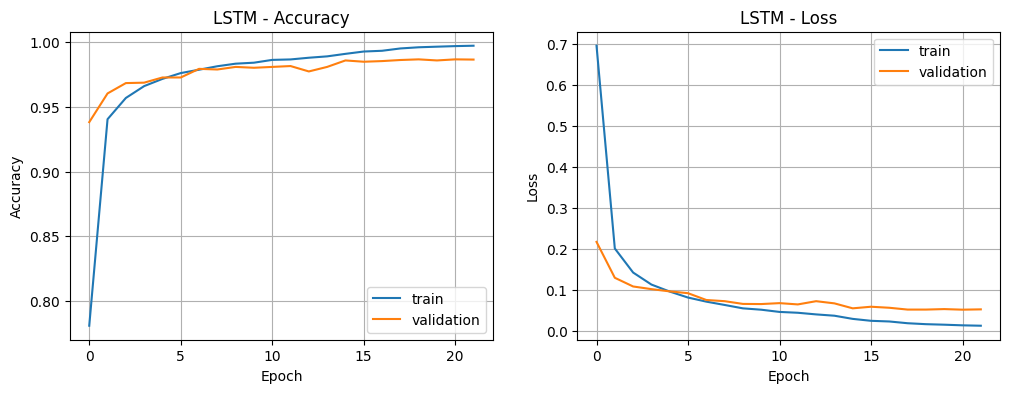

In [14]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1,
)

start_train = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[
        early_stopping,
        reduce_lr,
    ],
    verbose=1,
)

end_train = time.time()

print(
    "Training time:",
    f"{end_train - start_train:.2f} seconds",
)

plot_results(
    lstm_history,
    "LSTM",
)


## Evaluate the LSTM


In [15]:
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(
    f"LSTM test loss: "
    f"{lstm_test_loss:.4f}"
)
print(
    f"LSTM test accuracy: "
    f"{lstm_test_acc:.4f}"
)


LSTM test loss: 0.0572
LSTM test accuracy: 0.9830


# 3. Gated Recurrent Unit

## What is a GRU?

A Gated Recurrent Unit (GRU) is another gated recurrent architecture. It has a simpler internal structure than an LSTM because it does not maintain a separate cell state.

The two main gates are:

- **update gate**: determines how much previous information should be retained,
- **reset gate**: determines how much previous information should be ignored when computing the new candidate state.

## How does it learn?

Like the LSTM, the GRU learns the gate weights directly from the training data. These learned gates control how information moves through the sequence.

## What does it learn in this notebook?

For MNIST, the GRU learns which row-level image patterns should be retained across time steps and which information can be replaced by newer evidence. The final recurrent representation is then used to classify the digit.

Because the GRU uses fewer gates than an LSTM, it usually has fewer trainable parameters for the same hidden size while still being able to model longer dependencies better than a basic RNN.


In [16]:
gru_model = Sequential(
    [
        Input(
            shape=(28, 28)
        ),
        GRU(
            hidden_units
        ),
        Dense(
            10,
            activation="softmax",
        ),
    ],
    name="gru_mnist",
)

gru_model.summary()

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


Model: "gru_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,698 (73.04 KB)

 Trainable params: 18,698 (73.04 KB)

 Non-trainable params: 0 (0.00 B)

## Train the GRU


Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.7160 - loss: 0.8481 - val_accuracy: 0.9297 - val_loss: 0.2524 - learning_rate: 0.0010
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9286 - loss: 0.2406 - val_accuracy: 0.9617 - val_loss: 0.1479 - learning_rate: 0.0010
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.9518 - loss: 0.1627 - val_accuracy: 0.9693 - val_loss: 0.1116 - learning_rate: 0.0010
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9628 - loss: 0.1257 - val_accuracy: 0.9753 - val_loss: 0.0901 - learning_rate: 0.0010
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9696 - loss: 0.1034 - val_accuracy: 0.9790 - val_loss: 0.0780 - learning_rate: 0.0010
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9740 - loss: 0.0878 - val_accuracy: 0.9815 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.9

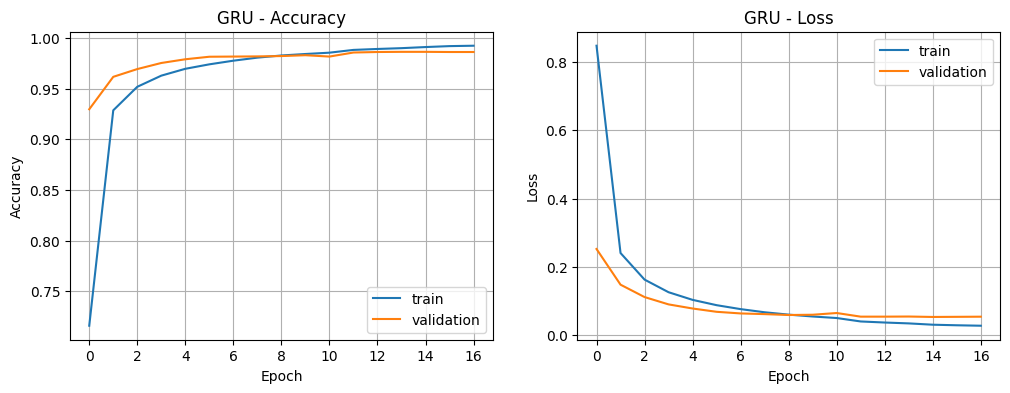

In [17]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1,
)

start_train = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[
        early_stopping,
        reduce_lr,
    ],
    verbose=1,
)

end_train = time.time()

print(
    "Training time:",
    f"{end_train - start_train:.2f} seconds",
)

plot_results(
    gru_history,
    "GRU",
)


## Evaluate the GRU


In [18]:
gru_test_loss, gru_test_acc = gru_model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(
    f"GRU test loss: "
    f"{gru_test_loss:.4f}"
)
print(
    f"GRU test accuracy: "
    f"{gru_test_acc:.4f}"
)


GRU test loss: 0.0593
GRU test accuracy: 0.9821


# Compare RNN, LSTM, and GRU


In [19]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Simple RNN",
            "LSTM",
            "GRU",
        ],
        "Parameters": [
            rnn_model.count_params(),
            lstm_model.count_params(),
            gru_model.count_params(),
        ],
        "Test Loss": [
            rnn_test_loss,
            lstm_test_loss,
            gru_test_loss,
        ],
        "Test Accuracy": [
            rnn_test_acc,
            lstm_test_acc,
            gru_test_acc,
        ],
    }
)

comparison.sort_values(
    by="Test Accuracy",
    ascending=False,
).reset_index(
    drop=True
)


,Model,Parameters,Test Loss,Test Accuracy
0,LSTM,24458,0.057229,0.9830
1,GRU,18698,0.059293,0.9821
2,Simple RNN,6602,0.122355,0.9669


The comparison shows the practical tradeoff among the three recurrent architectures. The Simple RNN has the simplest recurrence. LSTM adds a separate memory cell and three gates. GRU uses a more compact gated structure.

The best architecture should be selected from the measured validation and test performance rather than from complexity alone.


## Predictions from the Best Test-Accuracy Model


In [20]:
model_lookup = {
    "Simple RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
}

best_model_name = comparison.loc[
    comparison["Test Accuracy"].idxmax(),
    "Model",
]

best_model = model_lookup[
    best_model_name
]

pred_prob = best_model.predict(
    X_test,
    verbose=0,
)

pred_class = np.argmax(
    pred_prob,
    axis=1,
)

print(
    "Selected model:",
    best_model_name,
)
print(
    "Accuracy from predictions:",
    accuracy_score(
        y_test,
        pred_class,
    ),
)


Selected model: LSTM
Accuracy from predictions: 0.983


## Confusion Matrix


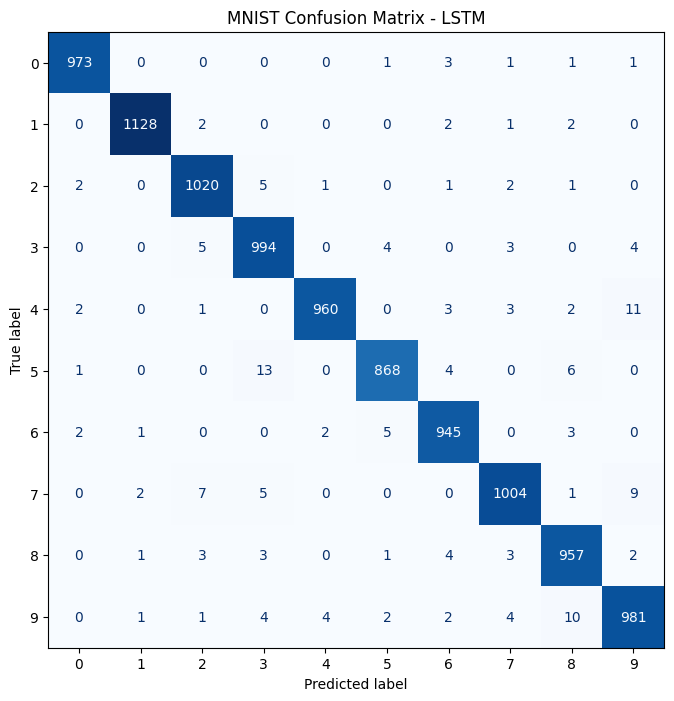

In [21]:
cm = confusion_matrix(
    y_test,
    pred_class,
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
)

fig, ax = plt.subplots(
    figsize=(8, 8)
)

display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)

plt.title(
    f"MNIST Confusion Matrix - {best_model_name}"
)

plt.show()


## Example Predictions


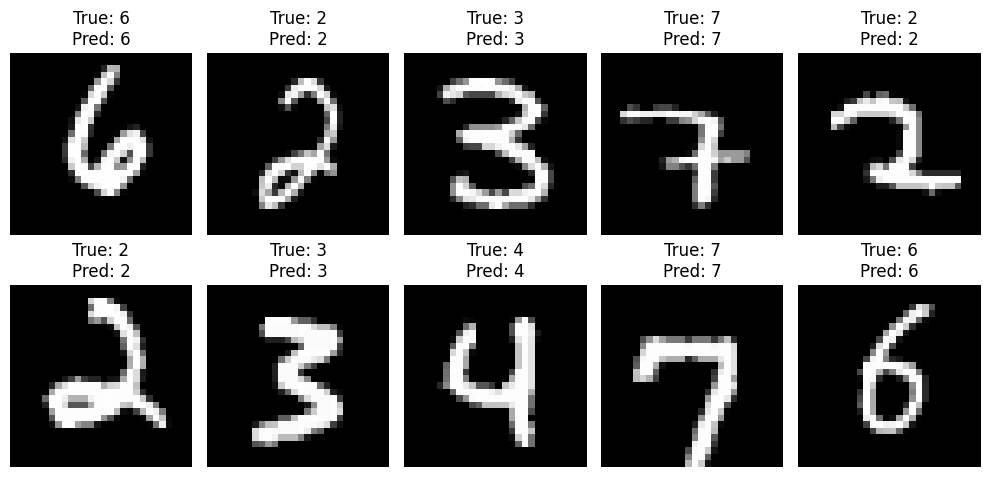

In [22]:
random_sel = np.random.choice(
    len(X_test),
    size=10,
    replace=False,
)

fig, ax = plt.subplots(
    2,
    5,
    figsize=(10, 5),
)

ax = ax.ravel()

for i, index in enumerate(random_sel):
    ax[i].imshow(
        X_test[index],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    ax[i].set_title(
        f"True: {y_test[index]}\n"
        f"Pred: {pred_class[index]}"
    )

    ax[i].axis("off")

plt.tight_layout()
plt.show()


## Key Takeaways

- A 2D image can be treated as a sequence when one spatial dimension is interpreted as time steps.
- Simple RNN provides the basic recurrent mechanism.
- LSTM introduces explicit gated memory to improve long-term information retention.
- GRU provides a simpler gated alternative with fewer parameters than a comparable LSTM.
- Using the same dataset and training settings makes the architectural comparison easier to interpret.
